# Man-in-the-middle attack (MITM) Scenario data analysis
---

In [39]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import csv
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import numpy as np

In [40]:
clean_data = "data\\processed\\captures1_v2\\clean\\MODBUS_ONLY_eth2dump-clean-1h_1.csv"
mitm_data = "data\\processed\\captures1_v2\\mitm\\MODBUS_ONLY_eth2dump-mitm-change-15m-1h_1.csv"

absolute_clean_path = (Path("../..") / clean_data).resolve()
absolute_mitm_path = (Path("../..") / mitm_data).resolve()

# Print the absolute paths
print("Absolute path to clean data:", absolute_clean_path)
print("Absolute path to mitm data:", absolute_mitm_path)

Absolute path to clean data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\captures1_v2\clean\MODBUS_ONLY_eth2dump-clean-1h_1.csv
Absolute path to mitm data: C:\Users\jabrantes\OneDrive - Brookhaven National Laboratory\Documents\CODE STUFF\BNL\Foundational-Model-for-Energy-Security\data\processed\captures1_v2\mitm\MODBUS_ONLY_eth2dump-mitm-change-15m-1h_1.csv


In [41]:
clean_data = pd.read_csv(absolute_clean_path)
mitm_data = pd.read_csv(absolute_mitm_path)

print(clean_data.columns.tolist())
display(clean_data.head())
print(f"Length of MITM data: {len(mitm_data)}")

['packet_number', 'timestamp', 'datetime', 'protocols', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'tcp_len', 'transaction_id', 'protocol_id', 'modbus_length', 'unit_id', 'function_code', 'reference_num', 'word_count', 'bit_count', 'byte_count', 'exception_code', 'pkt_len', 'is_request', 'is_response', 'is_exception', 'function_name', 'inter_arrival_time', 'time_from_start', 'rolling_iat_mean', 'rolling_iat_std', 'requests_per_second', 'flow_id', 'flow_pkt_count', 'unique_func_codes', 'round_trip_time']


,packet_number,timestamp,datetime,protocols,src_ip,dst_ip,src_port,dst_port,tcp_len,transaction_id,...,function_name,inter_arrival_time,time_from_start,rolling_iat_mean,rolling_iat_std,requests_per_second,flow_id,flow_pkt_count,unique_func_codes,round_trip_time
0,3,1.536440e+09,2018-09-08T16:54:30.205937,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,NaN,0.000000,NaN,NaN,1,172.27.224.250_172.27.224.70,1,1,0.003102
1,4,1.536440e+09,2018-09-08T16:54:30.209039,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.003102,0.003102,0.003102,NaN,1,172.27.224.250_172.27.224.70,2,1,0.003102
2,6,1.536440e+09,2018-09-08T16:54:30.517529,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.308490,0.311592,0.155796,0.215942,2,172.27.224.250_172.27.224.70,3,1,0.010858
3,7,1.536440e+09,2018-09-08T16:54:30.528387,Modbus/TCP,172.27.224.250,172.27.224.70,502,49205,31,0,...,Read Holding Registers,0.010858,0.322450,0.107483,0.174120,2,172.27.224.250_172.27.224.70,4,1,0.010858
4,10,1.536440e+09,2018-09-08T16:54:30.829737,Modbus/TCP,172.27.224.70,172.27.224.250,49205,502,12,0,...,Read Holding Registers,0.301350,0.623800,0.155950,0.172070,3,172.27.224.250_172.27.224.70,5,1,0.009315


Length of MITM data: 24234


In [42]:
# Define analysis window
start = 0
end = len(mitm_data)

# Round Trip Time detection and plotting

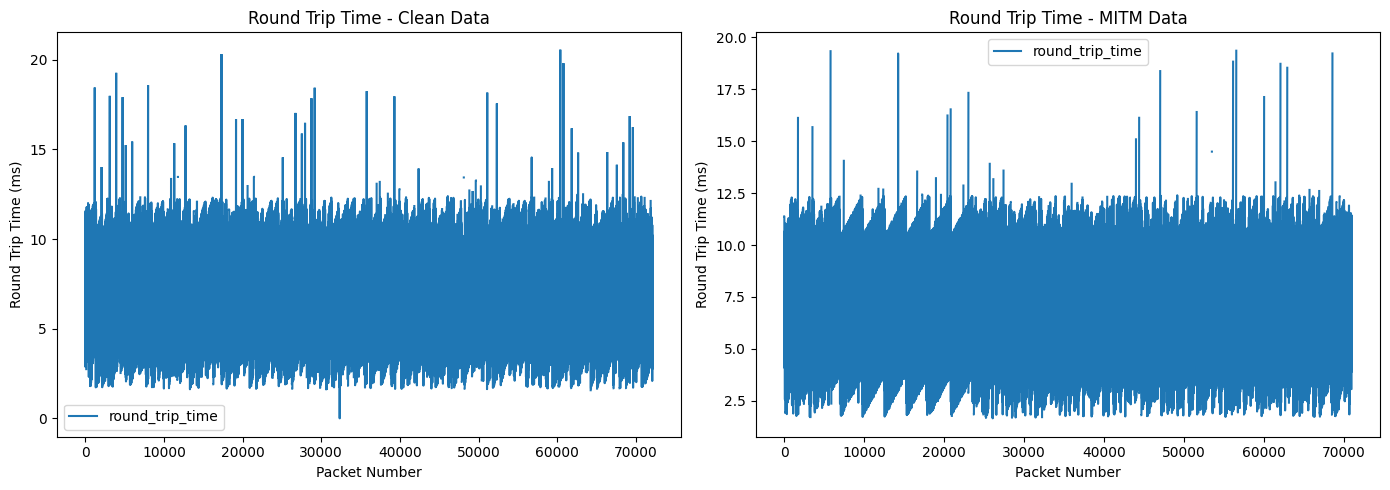

In [43]:
# Convert seconds to milliseconds for better readability
clean_data['round_trip_time'] = clean_data['round_trip_time'] * 1000
mitm_data['round_trip_time'] = mitm_data['round_trip_time'] * 1000

# Create figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.iloc[start:end].plot(kind='line', x='packet_number', y='round_trip_time', ax=ax1)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Round Trip Time - Clean Data')

# Plot MITM data
mitm_data.iloc[start:end].plot(kind='line', x='packet_number', y='round_trip_time', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Round Trip Time - MITM Data')

plt.tight_layout()
plt.show()

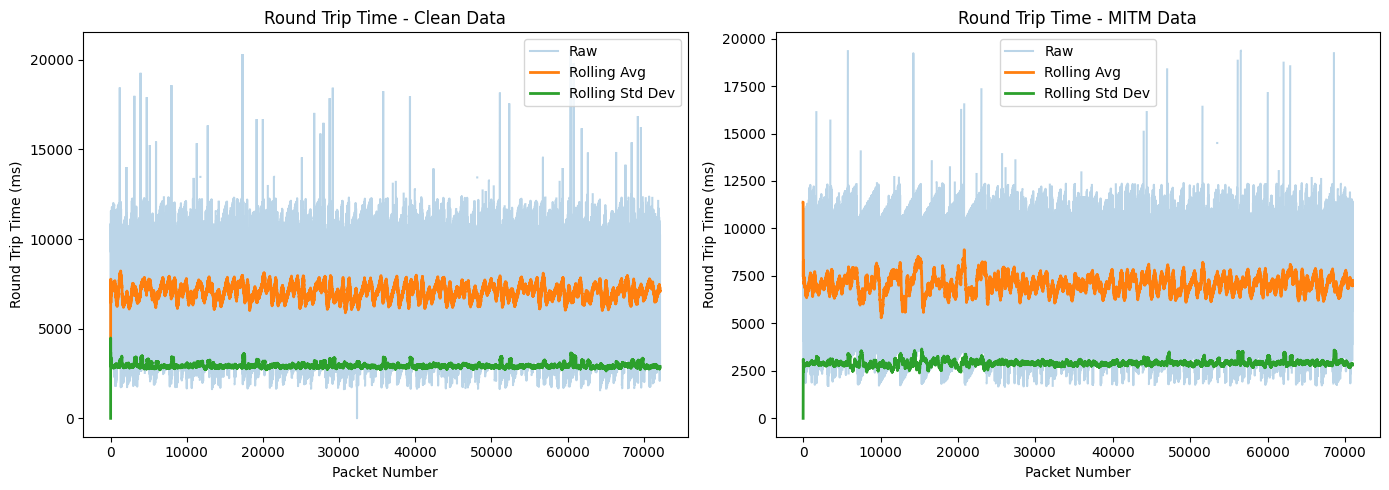

In [44]:
# Set rolling window size
window_size = 100

# Convert seconds to milliseconds
clean_data['round_trip_time'] = clean_data['round_trip_time'] * 1000
mitm_data['round_trip_time'] = mitm_data['round_trip_time'] * 1000

# Calculate rolling averages
clean_data['rtt_rolling_avg'] = clean_data['round_trip_time'].rolling(window=window_size, min_periods=1).mean()
mitm_data['rtt_rolling_avg'] = mitm_data['round_trip_time'].rolling(window=window_size, min_periods=1).mean()

# Calculate rolling std deviations
clean_data['rtt_rolling_std'] = clean_data['round_trip_time'].rolling(window=window_size, min_periods=1).std()
mitm_data['rtt_rolling_std'] = mitm_data['round_trip_time'].rolling(window=window_size, min_periods=1).std()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data with rolling average
subset_clean = clean_data.iloc[start:end]
ax1.plot(subset_clean['packet_number'], subset_clean['round_trip_time'], alpha=0.3, label='Raw')
ax1.plot(subset_clean['packet_number'], subset_clean['rtt_rolling_avg'], linewidth=2, label='Rolling Avg')
ax1.plot(subset_clean['packet_number'], subset_clean['rtt_rolling_std'], linewidth=2, label='Rolling Std Dev')
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Round Trip Time - Clean Data')
ax1.legend()

# Plot MITM data with rolling average
subset_mitm = mitm_data.iloc[start:end]
ax2.plot(subset_mitm['packet_number'], subset_mitm['round_trip_time'], alpha=0.3, label='Raw')
ax2.plot(subset_mitm['packet_number'], subset_mitm['rtt_rolling_avg'], linewidth=2, label='Rolling Avg')
ax2.plot(subset_mitm['packet_number'], subset_mitm['rtt_rolling_std'], linewidth=2, label='Rolling Std Dev')
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Round Trip Time - MITM Data')
ax2.legend()

plt.tight_layout()
plt.show()

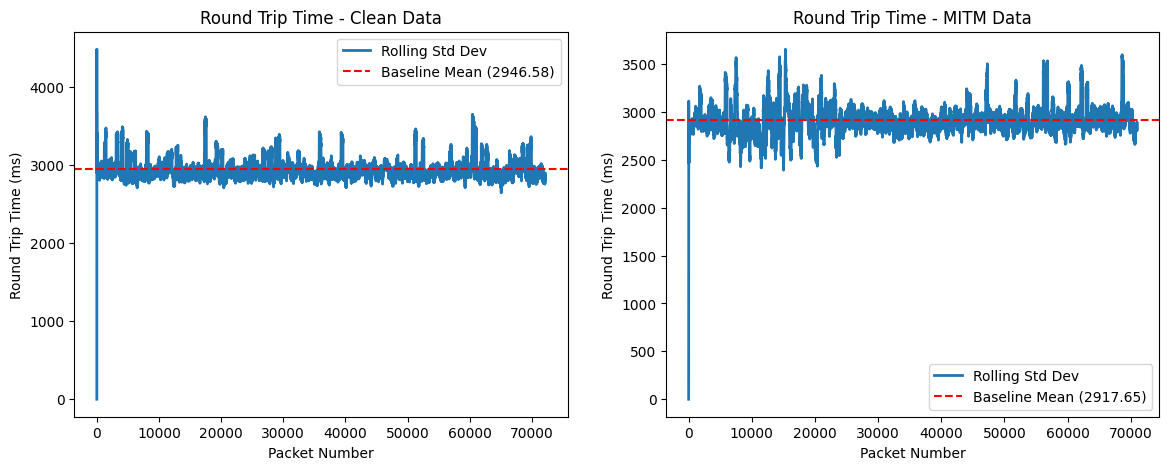

In [45]:
threshold = 0.5  # Standard deviations from the mean

clean_baseline_mean = clean_data['rtt_rolling_std'].mean()
clean_baseline_std = clean_data['rtt_rolling_std'].std()

mitm_baseline_mean = mitm_data['rtt_rolling_std'].mean()
mitm_baseline_std = mitm_data['rtt_rolling_std'].std()

#  Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data with rolling average
subset_clean = clean_data.iloc[start:end]
ax1.plot(subset_clean['packet_number'], subset_clean['rtt_rolling_std'], linewidth=2, label='Rolling Std Dev')
ax1.axhline(y=clean_baseline_mean, color='r', linestyle='--', label=f'Baseline Mean ({clean_baseline_mean:.2f})')
'''
ax1.axhline(y=clean_baseline_mean + threshold * clean_baseline_std, color='orange', linestyle='--', label=f'Anomaly Threshold (+{threshold}σ)')
ax1.axhline(y=clean_baseline_mean - threshold * clean_baseline_std, color='orange', linestyle='--', label=f'Anomaly Threshold (-{threshold}σ)')
'''
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Round Trip Time - Clean Data')
ax1.legend()

# Plot MITM data with rolling average
subset_mitm = mitm_data.iloc[start:end]
ax2.plot(subset_mitm['packet_number'], subset_mitm['rtt_rolling_std'], linewidth=2, label='Rolling Std Dev')
ax2.axhline(y=mitm_baseline_mean, color='r', linestyle='--', label=f'Baseline Mean ({mitm_baseline_mean:.2f})')
'''
ax2.axhline(y=mitm_baseline_mean + threshold * mitm_baseline_std, color='orange', linestyle='--', label=f'Anomaly Threshold (+{threshold}σ)')
ax2.axhline(y=mitm_baseline_mean - threshold * mitm_baseline_std, color='orange', linestyle='--', label=f'Anomaly Threshold (-{threshold}σ)')
'''
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Round Trip Time - MITM Data')
ax2.legend()


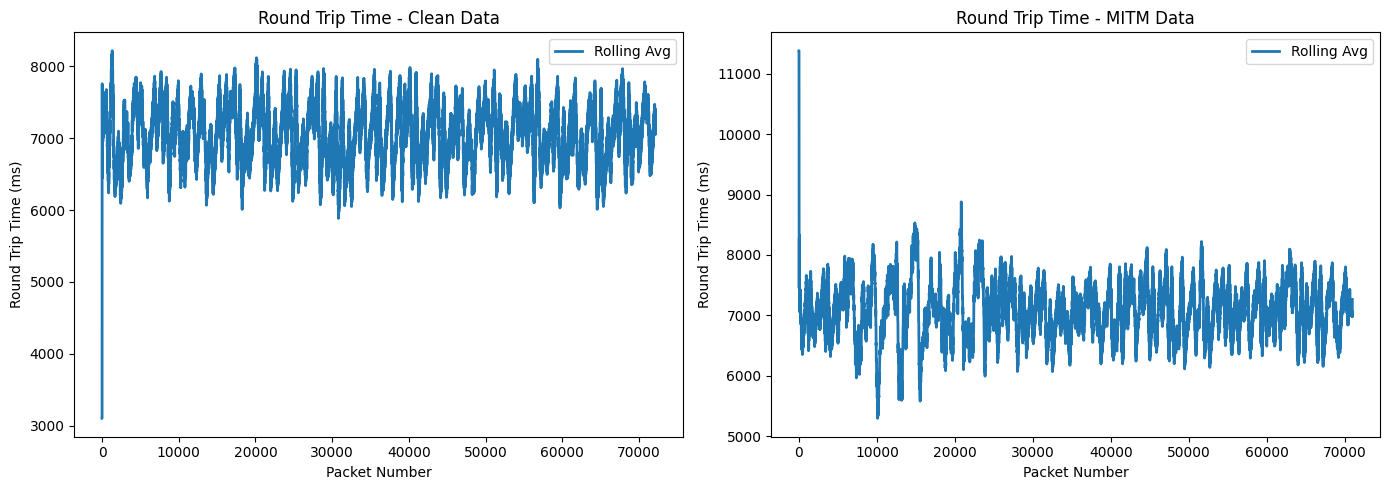

In [46]:
# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data with rolling average
subset_clean = clean_data.iloc[start:end]
ax1.plot(subset_clean['packet_number'], subset_clean['rtt_rolling_avg'], linewidth=2, label='Rolling Avg')
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Round Trip Time (ms)')
ax1.set_title('Round Trip Time - Clean Data')
ax1.legend()

# Plot MITM data with rolling average
subset_mitm = mitm_data.iloc[start:end]
ax2.plot(subset_mitm['packet_number'], subset_mitm['rtt_rolling_avg'], linewidth=2, label='Rolling Avg')
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Round Trip Time (ms)')
ax2.set_title('Round Trip Time - MITM Data')
ax2.legend()

plt.tight_layout()
plt.show()

# Inter-Arrival Time detection and plotting


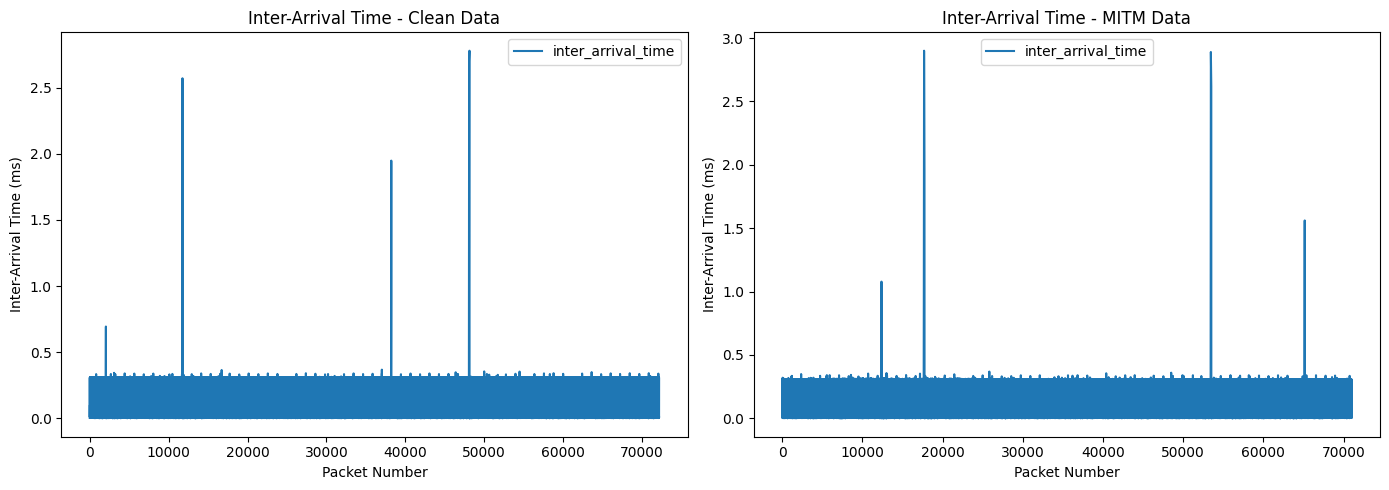

In [47]:
# Create figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.plot(kind='line', x='packet_number', y='inter_arrival_time', ax=ax1)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Inter-Arrival Time (ms)')
ax1.set_title('Inter-Arrival Time - Clean Data')

# Plot MITM data
mitm_data.plot(kind='line', x='packet_number', y='inter_arrival_time', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Inter-Arrival Time (ms)')
ax2.set_title('Inter-Arrival Time - MITM Data')

plt.tight_layout()
plt.show()

# Flow Packet Count detection and plotting

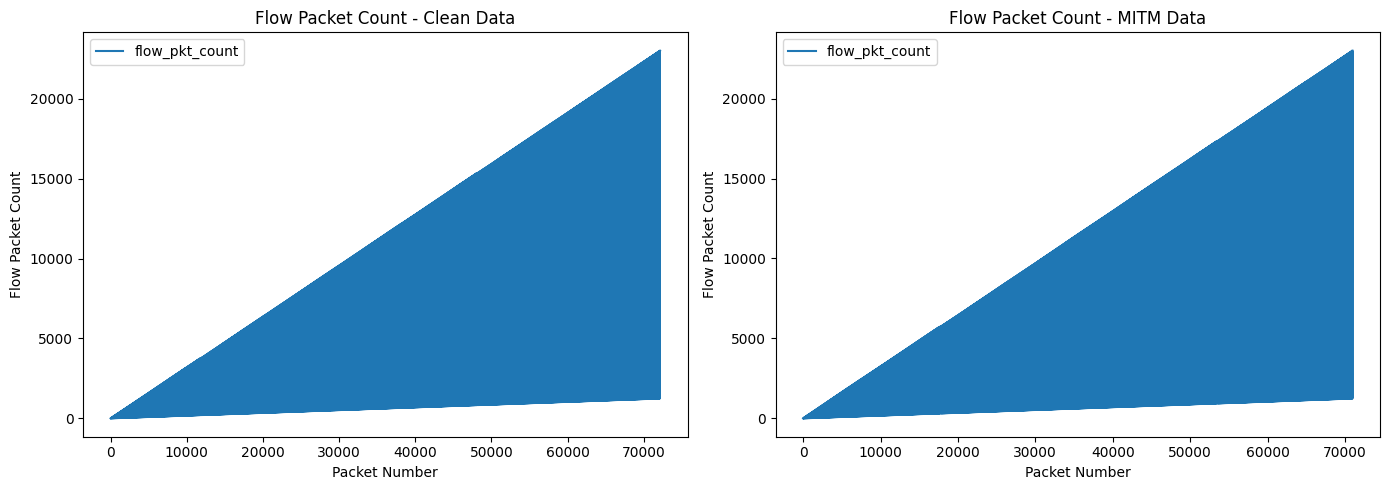

In [48]:
# Create figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.plot(kind='line', x='packet_number', y='flow_pkt_count', ax=ax1)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Flow Packet Count')
ax1.set_title('Flow Packet Count - Clean Data')

# Plot MITM data
mitm_data.plot(kind='line', x='packet_number', y='flow_pkt_count', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Flow Packet Count')
ax2.set_title('Flow Packet Count - MITM Data')

plt.tight_layout()
plt.show()

# Requests Per Second detection and plotting

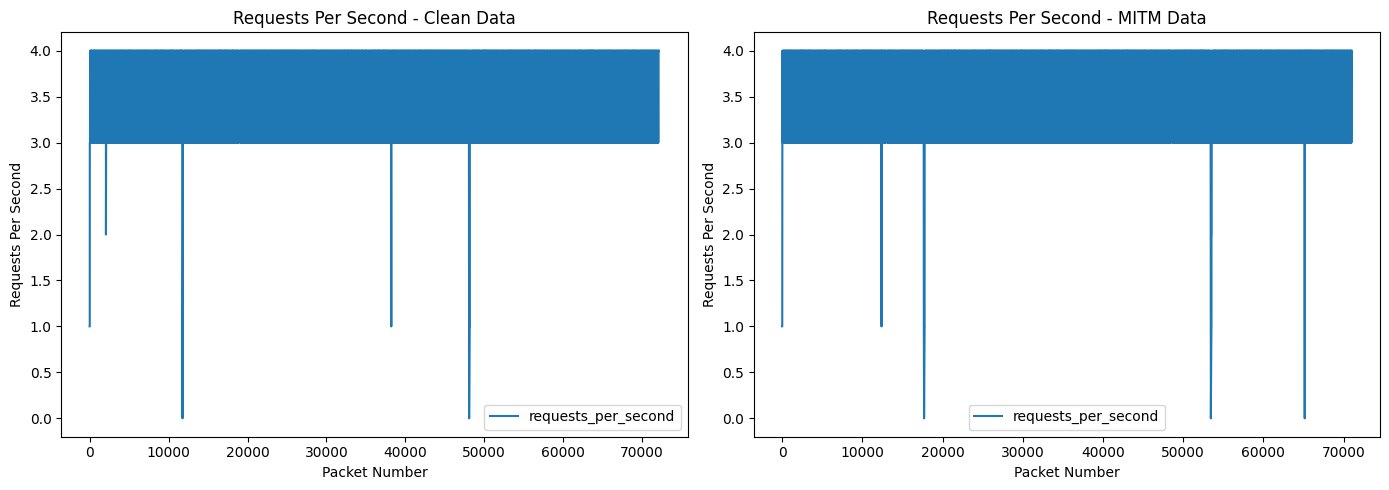

In [49]:
# Create figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.plot(kind='line', x='packet_number', y='requests_per_second', ax=ax1)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Requests Per Second')
ax1.set_title('Requests Per Second - Clean Data')

# Plot MITM data
mitm_data.plot(kind='line', x='packet_number', y='requests_per_second', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Requests Per Second')
ax2.set_title('Requests Per Second - MITM Data')

plt.tight_layout()
plt.show()

# Function Codes detection and plotting

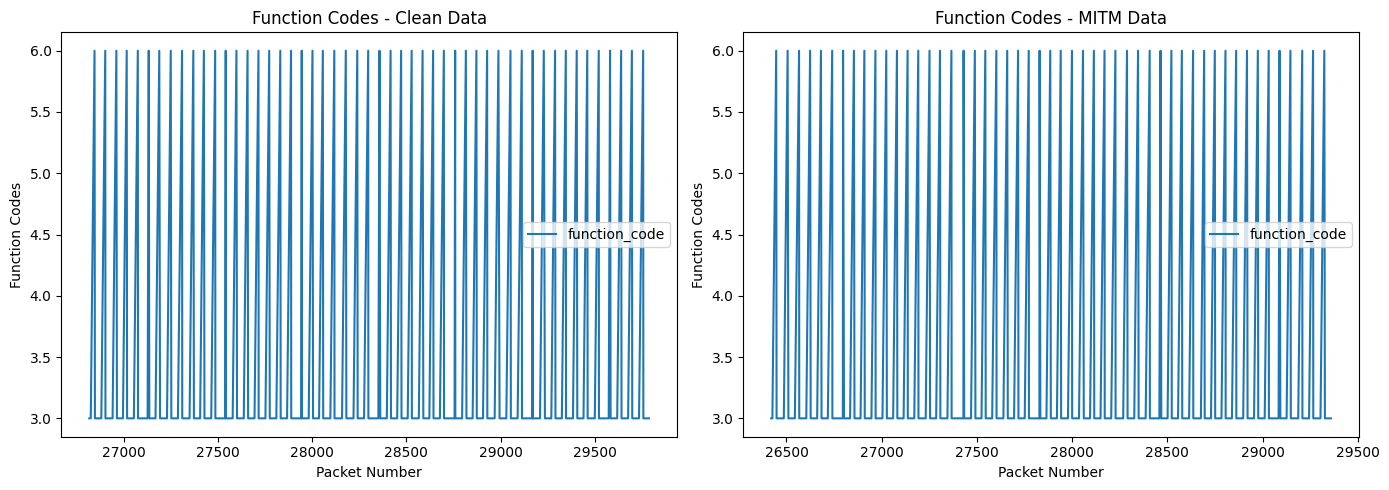

In [50]:
# Create figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.iloc[9000:10000].plot(kind='line', x='packet_number', y='function_code', ax=ax1)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Function Codes')
ax1.set_title('Function Codes - Clean Data')

# Plot MITM data
mitm_data.iloc[9000:10000].plot(kind='line', x='packet_number', y='function_code', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Function Codes')
ax2.set_title('Function Codes - MITM Data')

plt.tight_layout()
plt.show()

# Packet Length Analysis

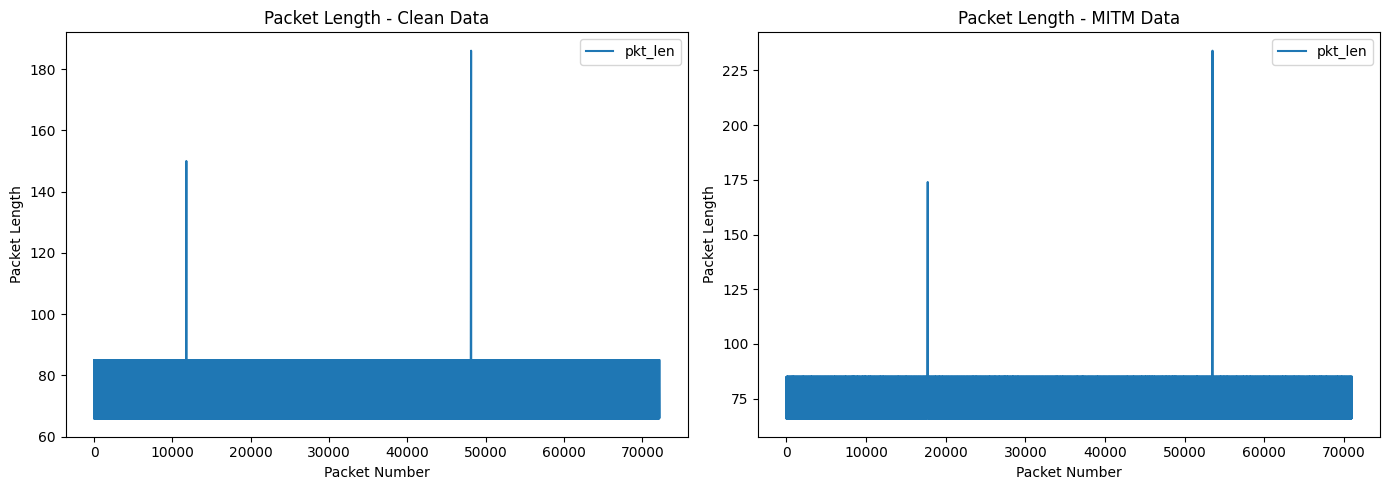

In [51]:
# Create figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.plot(kind='line', x='packet_number', y='pkt_len', ax=ax1)
ax1.set_xlabel('Packet Number')
ax1.set_ylabel('Packet Length')
ax1.set_title('Packet Length - Clean Data')

# Plot MITM data
mitm_data.plot(kind='line', x='packet_number', y='pkt_len', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Packet Length')
ax2.set_title('Packet Length - MITM Data')

plt.tight_layout()
plt.show()

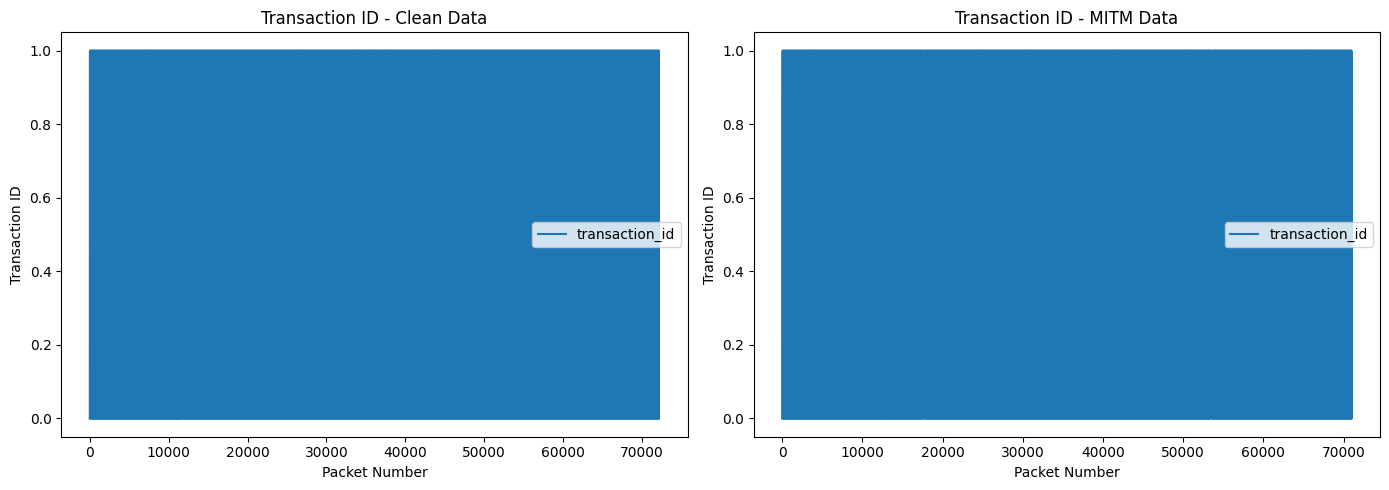

In [52]:
# Transaction ID data analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot clean data
clean_data.plot(kind='line', x='packet_number', y='transaction_id', ax=ax1)
ax1.set_xlabel('Packet Number') 
ax1.set_ylabel('Transaction ID')
ax1.set_title('Transaction ID - Clean Data')

# Plot MITM data
mitm_data.plot(kind='line', x='packet_number', y='transaction_id', ax=ax2)
ax2.set_xlabel('Packet Number')
ax2.set_ylabel('Transaction ID')
ax2.set_title('Transaction ID - MITM Data')

plt.tight_layout()
plt.show()


In [53]:
# Clean data src-dst diversity analysis
# How many different destinations each source contacts
src_diversity = clean_data.groupby('src_ip')['dst_ip'].nunique()

# How many different sources each destination receives from
dst_diversity = clean_data.groupby('dst_ip')['src_ip'].nunique()

print("Unique destinations per source (sample):")
display(src_diversity.head())
print("\nUnique sources per destination (sample):")
display(dst_diversity.head())

# MITM data src-dst diversity analysis
# How many different destinations each source contacts
src_diversity_mitm = mitm_data.groupby('src_ip')['dst_ip'].nunique()

# How many different sources each destination receives from
dst_diversity_mitm = mitm_data.groupby('dst_ip')['src_ip'].nunique()

print("Unique destinations per source (sample):")
display(src_diversity_mitm.head())
print("\nUnique sources per destination (sample):")
display(dst_diversity_mitm.head())



Unique destinations per source (sample):


src_ip
172.27.224.250    2
172.27.224.70     1
Name: dst_ip, dtype: int64


Unique sources per destination (sample):


dst_ip
172.27.224.250    1
172.27.224.251    1
172.27.224.70     1
Name: src_ip, dtype: int64

Unique destinations per source (sample):


src_ip
172.27.224.250    2
172.27.224.70     1
Name: dst_ip, dtype: int64


Unique sources per destination (sample):


dst_ip
172.27.224.250    1
172.27.224.251    1
172.27.224.70     1
Name: src_ip, dtype: int64